1. Load Data & Basic Processing

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, mean_squared_error
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor
import seaborn as sns

# Load data
df = pd.read_csv("/content/drive/MyDrive/Projects/csv_files/csv_files/hist_with_sentiment.csv")

# Drop rows with missing essential values
df = df.dropna(subset=["Closed PnL", "trade_volume", "risk_exposure", "value"])


2. Simple Feature Selection

In [4]:
features = [
    "trade_volume",
    "risk_exposure",
    "value",            # sentiment score
]

X = df[features].copy()
y_clf = (df["Closed PnL"] < 0).astype(int)   # simple loss classification
y_reg = df["Closed PnL"]                     # regression target


3. Train-Test Split

In [5]:
X_train, X_test, y_train_clf, y_test_clf = train_test_split(
    X, y_clf, test_size=0.2, random_state=42
)

_, _, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)


4. SIMPLE CLASSIFICATION MODEL

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.92      1.00      0.96     38721
           1       0.00      0.00      0.00      3524

    accuracy                           0.92     42245
   macro avg       0.46      0.50      0.48     42245
weighted avg       0.84      0.92      0.88     42245



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


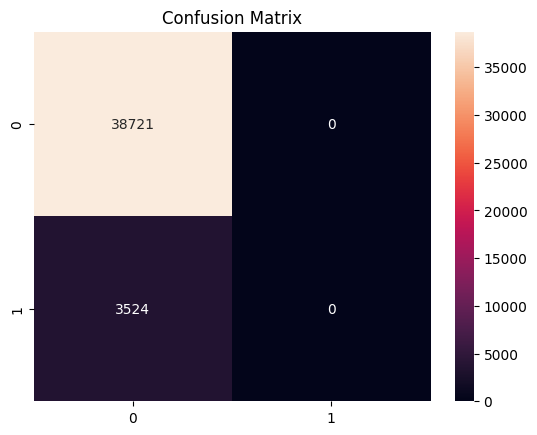

<Figure size 640x480 with 0 Axes>

In [9]:
clf = LogisticRegression()
clf.fit(X_train, y_train_clf)

y_pred = clf.predict(X_test)

print("=== Classification Report ===")
print(classification_report(y_test_clf, y_pred))

cm = confusion_matrix(y_test_clf, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()
plt.savefig('/content/drive/MyDrive/Projects/csv_files/outputs/confusion_matrix.png')

5. SIMPLE REGRESSION MODEL

RMSE: 1255.3056514355815


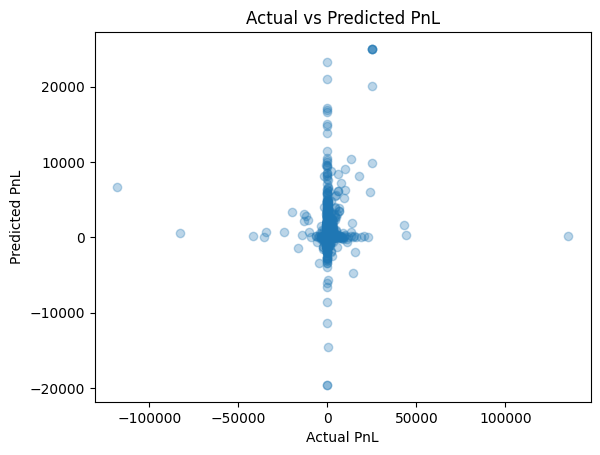

<Figure size 640x480 with 0 Axes>

In [10]:
reg = RandomForestRegressor(n_estimators=20, random_state=42)
reg.fit(X_train, y_train_reg)

y_pred_reg = reg.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
print("RMSE:", rmse)

plt.scatter(y_test_reg, y_pred_reg, alpha=0.3)
plt.xlabel("Actual PnL")
plt.ylabel("Predicted PnL")
plt.title("Actual vs Predicted PnL")
plt.show()
plt.savefig('/content/drive/MyDrive/Projects/csv_files/outputs/pnl_actual_vs_pred.png')

6. Display Feature Importance

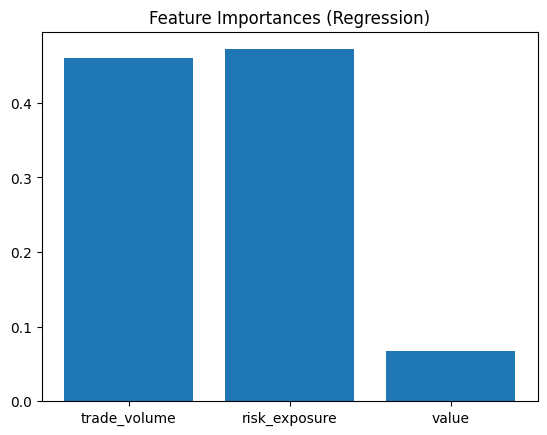

<Figure size 640x480 with 0 Axes>

In [11]:
importances = reg.feature_importances_
plt.bar(features, importances)
plt.title("Feature Importances (Regression)")
plt.show()
plt.savefig('/content/drive/MyDrive/Projects/csv_files/outputs/reg_feature_importance.png')